## Geodesic Calculus on point cloud

In this notebook geodesics are computed on a generated "half moon" point cloud. 
A pretrained learned implicit representation is saved in [saved_models/latentrep_state_dict_best.pth](saved_models/latentrep_state_dict_best.pth). 

To train the latent representation yourself use (modify the paths in [saved_models/args_latentrep.json](saved_models/args_latentrep.json))

  `python scripts/train_latent_representation.py --config examples/Point_Cloud_example/saved_models/args_latentrep.json`


In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from latentgeodesics import setup_latent_network, GeodesicSolverNumpy
base_path = Path.cwd()

### load latent representation

In [2]:
model_path = base_path / "saved_models/"
network_path = model_path / "latentrep_state_dict_best.pth"
network_weights = torch.load(network_path)
args = json.load(open(model_path / "args_latentrep.json", "r"))

In [3]:
latentprojector = setup_latent_network(args['architecture'])
latentprojector.load_state_dict(network_weights)
device = latentprojector.device()

#representation functions
phi = latentprojector.phi(use_torch=False)
dphi = latentprojector.dphi(use_torch=False)

In [4]:
data_samples  = np.load(base_path / "data/samples.npy")

In [5]:
ldim = args['architecture']['latent_dim']

In [6]:
GeodesicSolver = GeodesicSolverNumpy(ldim,phi,dphi)

# visualize learned representation

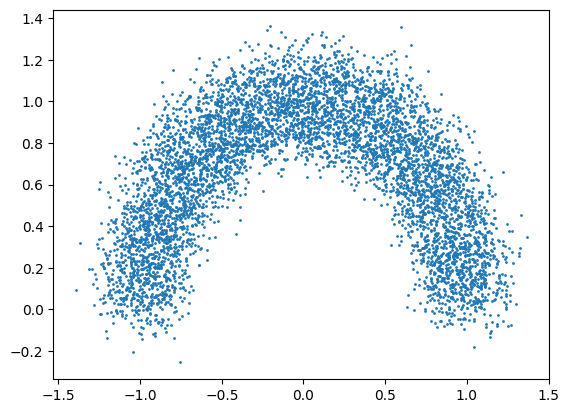

In [7]:
plt.scatter(data_samples[:,0], data_samples[:,1], s=1, marker ='o')

/tmp/ipykernel_22365/2088242199.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latent_coord = torch.tensor(coord.reshape(-1,ldim), device = device, dtype = torch.float32, requires_grad = True)


[]

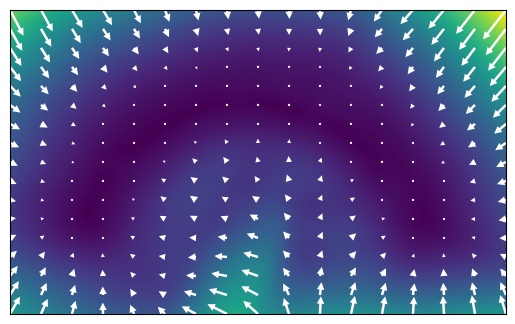

In [8]:
#visualize representation
def levels(coord):
    phi_level = torch.norm(latentprojector.latent_space_deviation(coord), dim = 1)
    return phi_level
def projection(coord):
    latent_coord = torch.tensor(coord.reshape(-1,ldim), device = device, dtype = torch.float32, requires_grad = True)
    return latentprojector.latent_space_deviation(latent_coord)

a = 0
b = 1
x_min, x_max = data_samples[:, 0].min(), data_samples[:, 0].max()
y_min, y_max = data_samples[:, 1].min(), data_samples[:, 1].max()
VOLUME_PLOT_RESOLUTION =128*2
DIMENSION = 2
offset = 0.1

X = np.linspace(x_min - offset, x_max + offset,VOLUME_PLOT_RESOLUTION, dtype='float32')
Y = np.linspace(y_min - offset, y_max + offset, VOLUME_PLOT_RESOLUTION, dtype='float32')

XX, YY = np.meshgrid(X, Y)
num = XX.size
coords_flat = np.column_stack([XX.ravel(), YY.ravel()])  # Shape (n, 3)

all_data_dim = torch.tensor(coords_flat, dtype=torch.float32)
batch_size = 2048
split_data = torch.split(all_data_dim, batch_size)

with torch.no_grad():
        value = torch.cat([levels(v.to(latentprojector.device())) for v in split_data]).cpu()

X = np.linspace(x_min - offset, x_max + offset,int(VOLUME_PLOT_RESOLUTION/15), dtype='float32')
Y = np.linspace(y_min - offset, y_max + offset, int(VOLUME_PLOT_RESOLUTION/15), dtype='float32')

XX, YY = np.meshgrid(X, Y)
num = XX.size
coords_flat = np.column_stack([XX.ravel(), YY.ravel()])  # Shape (n, 3)

all_data_dim = torch.tensor(coords_flat, dtype=torch.float32)
batch_size = 2048
split_data = torch.split(all_data_dim, batch_size)

with torch.no_grad():
        valueproj = torch.cat([projection(v.to(latentprojector.device())) for v in split_data]).cpu()
valueproj = valueproj
projdir = 0.1* valueproj

fig  =plt.figure()
ax = fig.add_subplot(111)
contour = ax.imshow(value.detach().numpy().flatten().reshape(VOLUME_PLOT_RESOLUTION, VOLUME_PLOT_RESOLUTION), extent=[ x_min-offset, x_max +offset, y_min-offset, y_max+offset ] ,cmap = 'viridis', origin='lower') #, levels=128*2,alpha=1)
q = ax.quiver(coords_flat[:,0], coords_flat[:,1], projdir[:,0], projdir[:,1], width=0.005, scale=0.3, headwidth=3,headlength=3,headaxislength=3, color = 'white') #, headwidth=4,headlength=3,headaxislength=3, color='white')
ax.set_aspect('equal')
ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([])#

## Computing geodesics

We compute geodesics between randomly chosen start end and points.

In [9]:
def sample_start_end(data, n ,epsilon):
    """
    returns n indices of datapoints that have at least distance epsilon
    """
    N = len(data)
    start_points = []
    end_points = []

    for _i in range(n):
        idx_start = np.random.randint(0, N)
        start_points.append(data[idx_start])
    
        idx_end = np.random.randint(0, N)

        while np.linalg.norm(data[idx_start]- data[idx_end]) < epsilon:
                idx_end = np.random.randint(0, N)

        end_points.append(data[idx_end])
    return np.array(start_points), np.array(end_points)

In [ ]:
p0, p1 = sample_start_end(data_samples, 5, 0.5)
geodesics = len(p0)*[None]
for i in range(len(p0)):
    K = 30
    xA = p0[i]
    xB = p1[i]

    geodesics[i] = GeodesicSolver.AugLagrangeMinimize(K,xA=xA, xB=xB, mu=100, maxmu=10e2, alpha=2, disp=False)

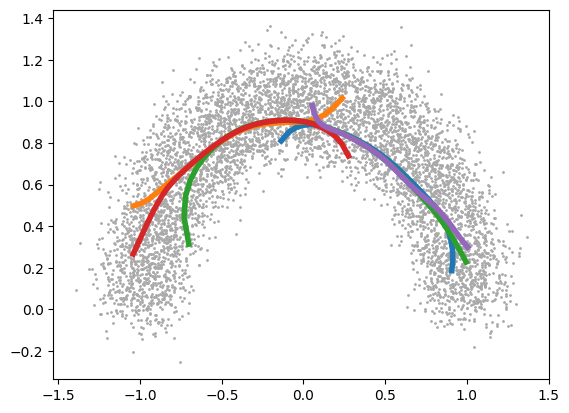

In [11]:
for i in range(len(p0)):
    plt.plot(geodesics[i][:,0], geodesics[i][:,1], alpha=1, lw=4)

plt.scatter(data_samples[:,0], data_samples[:,1], c='darkgray', s=1)

In [ ]:
xA = np.array([-1,0])
xB = np.array([1,0])
K = 30

geodesic = GeodesicSolver.AugLagrangeMinimize(K,xA=xA, xB=xB, mu=100, maxmu=10e2, tol=1e-10, alpha=2)

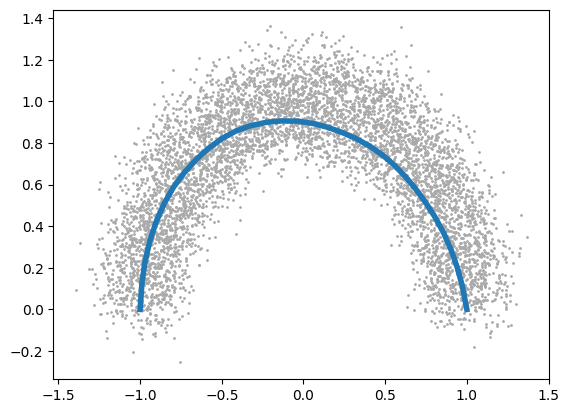

In [13]:
plt.plot(geodesic[:,0], geodesic[:,1], alpha=1, lw  =4)
plt.scatter(data_samples[:,0], data_samples[:,1], c='darkgray', s=1)

## Exponential

In [14]:
from latentgeodesics import KExponentialNumpy

In [ ]:
p0 = np.array([-1,0])  # 1xD
p1 = np.array([-0.9688, 0.167])
K=30
v = K*(p1-p0)
exp = KExponentialNumpy(phi, dphi, p0, v, K, firstStep='linear', constrfact=8.)

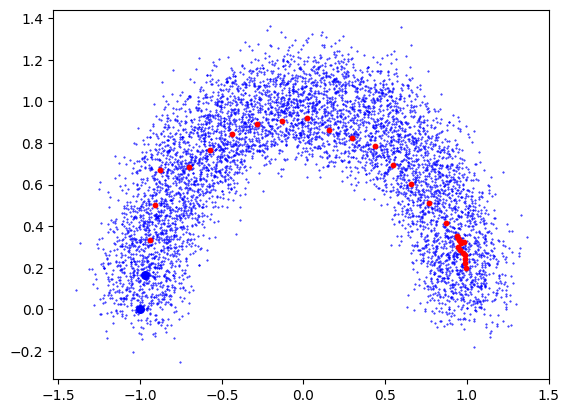

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(data_samples[:,0], data_samples[:,1],  c='b', marker='o', s=0.2)
ax.scatter(exp[:,0], exp[:,1], c='r', marker='o', s=10)
ax.scatter(exp[0,0], exp[0,1], c='b', marker='o', s=30)
ax.scatter(exp[1,0], exp[1,1], c='b', marker='o', s=30)
